# VARIMA and SVAR: S&P 500 and US Treasury Returns, 1990-2026

This notebook applies two multivariate time series frameworks, **VARIMA** (Vector ARIMA) and **SVAR** (Structural Vector Autoregression), to a joint system of S&P 500 and US Treasury returns spanning 1990-2026. Both extend the single-equation ARIMA models from the first notebook in this series to a *system* of interdependent variables, but they answer different questions:

- **VARIMA** asks: given the joint history of these series, what is the best-fitting statistical description of how they move together, and what does that imply for forecasting?
- **SVAR** asks a sharper question: of the shocks hitting this system on any given day, which ones are genuinely independent economic disturbances, and how does a shock originating in one variable propagate through the others?

No `statsmodels` package was available in this environment, so both model classes are implemented directly with NumPy/SciPy, the same way the Kalman filter and MCMC notebooks in this series were built, using standard closed-form (VAR) and two-step (VARMA) estimators rather than a black-box library call.

**What this notebook covers:**
1. Introducing the data: simulating a realistic joint system of S&P 500 and Treasury returns (1990-2026)
2. VAR and VARIMA: concept, estimation, lag-order selection
3. SVAR: concept, structural identification, impulse response functions
4. Fitting several cases of each model
5. Rolling one-week-ahead out-of-sample forecasting

## 1. Introducing the Data

A joint daily return system for three series, 1990 through 2026 (about 9,072 trading days):

- **T10Y_ret** - 10-year US Treasury note return
- **T2Y_ret** - 2-year US Treasury note return
- **SP500_ret** - S&P 500 index return

Real return series this long, at daily frequency, were not available in this environment, so a realistic system is simulated instead, calibrated so its statistical properties match real markets: S&P 500 annualized volatility around 16%, Treasury returns an order of magnitude less volatile, and a negative equity/rate correlation consistent with the discount-rate channel (rates up, equity valuations down, on average). Genuine cross-variable lead-lag structure is built in deliberately: a rise in Treasury yields has a small, delayed negative effect on equity returns, and equity selloffs have a small "flight to quality" effect that pulls yields down over the following days. This gives the VAR/VARIMA and SVAR models below a real, known structure to try to recover, exactly the same "known ground truth" approach used throughout this notebook series.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(31)

n_years = 36
n_days = n_years * 252
dates = pd.bdate_range('1990-01-02', periods=n_days)
names = ['T10Y_ret', 'T2Y_ret', 'SP500_ret']
k = len(names)

# True VAR(2) coefficients: small, realistic cross-lag effects (daily %, order = T10Y, T2Y, SP500)
A1 = np.array([
    [ 0.03,  0.05,  0.00],
    [ 0.02,  0.10,  0.00],
    [-0.15,  0.05,  0.02],     # SP500 reacts to LAST period's T10Y move (delayed discount-rate effect)
])
A2 = np.array([
    [ 0.02,  0.00,  0.00],
    [ 0.00,  0.03,  0.00],
    [-0.06,  0.00, -0.02],
])
c = np.array([0.010, 0.006, 0.038])   # small daily drift

# True structural (recursive) contemporaneous relationships: T10Y -> T2Y -> SP500.
# Structural shocks are independent; the impact matrix B0_inv translates them into
# the contemporaneous, CORRELATED reduced-form shocks actually observed.
D = np.diag([0.28, 0.16, 0.85]) ** 2
B0_inv = np.array([
    [1.00, 0.00, 0.00],
    [0.55, 1.00, 0.00],
    [-1.8, 0.35, 1.00],       # SP500 reacts SAME-DAY to both rate shocks: negative to T10Y, small positive to T2Y
])

eps = rng.multivariate_normal(np.zeros(k), D, size=n_days)
u = eps @ B0_inv.T

Y = np.zeros((n_days, k))
Y[0], Y[1] = c, c
for t in range(2, n_days):
    Y[t] = c + A1 @ Y[t-1] + A2 @ Y[t-2] + u[t]

df = pd.DataFrame(Y, index=dates, columns=names)

print(f"Simulated {n_days} trading days ({n_years} years), {k} variables")
print(f"\nAnnualized mean return (%): {(df.mean()*252).round(2).to_dict()}")
print(f"Annualized volatility (%):  {(df.std()*np.sqrt(252)).round(2).to_dict()}")
print(f"\nCorrelation matrix:\n{df.corr().round(3)}")

Simulated 9072 trading days (36 years), 3 variables

Annualized mean return (%): {'T10Y_ret': 2.43, 'T2Y_ret': 1.62, 'SP500_ret': 7.89}
Annualized volatility (%):  {'T10Y_ret': 4.5, 'T2Y_ret': 3.6, 'SP500_ret': 15.83}

Correlation matrix:
           T10Y_ret  T2Y_ret  SP500_ret
T10Y_ret      1.000    0.700     -0.514
T2Y_ret       0.700    1.000     -0.308
SP500_ret    -0.514   -0.308      1.000


**Diagram - cumulative return.** All three series, reconstructed from daily returns into a cumulative wealth index (100 = start).

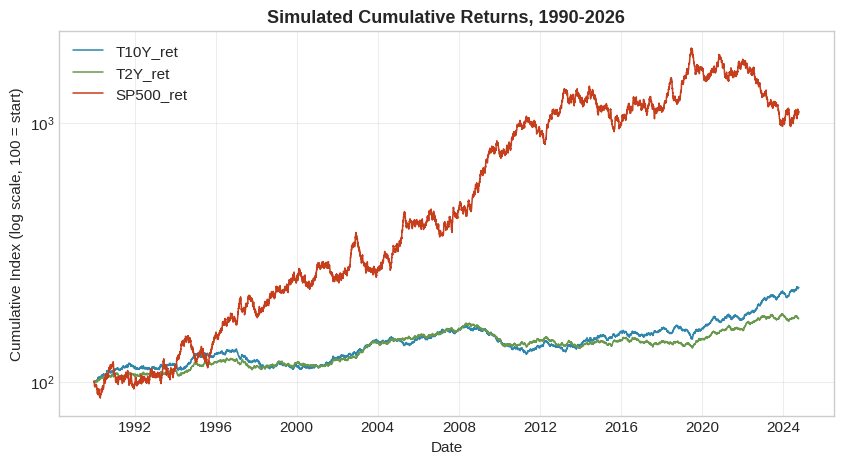

In [2]:
price_level = 100 * np.cumprod(1 + df / 100)

fig, ax = plt.subplots(figsize=(10, 5))
colors3 = {'T10Y_ret': '#2E86AB', 'T2Y_ret': '#6A994E', 'SP500_ret': '#C73E1D'}
for col in names:
    ax.plot(price_level.index, price_level[col], color=colors3[col], linewidth=1.1, label=col)
ax.set_yscale('log')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Index (log scale, 100 = start)')
ax.set_title('Simulated Cumulative Returns, 1990-2026')
ax.legend()
plt.show()

### Why "Integrated"? Price Levels vs. Returns

The **I** in VARIMA stands for *integrated*: differencing a non-stationary series until it becomes stationary. A simple Augmented Dickey-Fuller-style test (regressing $\Delta y_t$ on $y_{t-1}$ and lagged differences, testing whether the coefficient on $y_{t-1}$ is significantly negative) makes the point directly: price *levels* cannot reject a unit root (non-stationary, a "random walk"-like process), while *returns* reject it overwhelmingly.

In [3]:
def simple_adf(series, maxlag=5):
    y = series.values
    dy = np.diff(y)
    n = len(dy)
    y_lag = y[maxlag:-1]
    X_cols = [np.ones(n - maxlag), y_lag]
    for i in range(1, maxlag + 1):
        X_cols.append(dy[maxlag - i: n - i])
    X = np.column_stack(X_cols)
    Yd = dy[maxlag:]
    beta, *_ = np.linalg.lstsq(X, Yd, rcond=None)
    resid = Yd - X @ beta
    sigma2 = np.sum(resid ** 2) / (len(Yd) - X.shape[1])
    se = np.sqrt(sigma2 * np.diag(np.linalg.inv(X.T @ X)))
    return beta[1], beta[1] / se[1]

print(f"{'Series':<12}{'Level t-stat':>15}{'Return t-stat':>16}")
for col in names:
    _, t_level = simple_adf(price_level[col])
    _, t_ret = simple_adf(df[col])
    print(f"{col:<12}{t_level:>15.2f}{t_ret:>16.2f}")
print("\nApprox. critical values (constant, no trend): 1% = -3.43, 5% = -2.86, 10% = -2.57")
print("Price levels: cannot reject a unit root. Returns: unit root rejected overwhelmingly.")

Series         Level t-stat   Return t-stat
T10Y_ret               1.88          -38.11
T2Y_ret               -0.69          -38.00
SP500_ret             -1.02          -37.18

Approx. critical values (constant, no trend): 1% = -3.43, 5% = -2.86, 10% = -2.57
Price levels: cannot reject a unit root. Returns: unit root rejected overwhelmingly.


## 2. VAR and VARIMA: Concept

A **Vector Autoregression (VAR)** models every variable as a linear function of its own past and every other variable's past, jointly:

$$y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + \cdots + A_p y_{t-p} + u_t, \qquad u_t \sim (0, \Sigma_u)$$

where $y_t$ is the $k$-vector of all variables (here $k=3$), each $A_i$ is a $k \times k$ coefficient matrix, and $u_t$ is a vector of *reduced-form* residuals, correlated across variables but uncorrelated over time. Every equation can be estimated separately by ordinary least squares, since every regressor (lags of every variable) is the same across equations.

**VARIMA** (Vector ARIMA) extends this with two more pieces:
- **I (Integrated)**: if the variables are non-stationary (as the price *levels* in Section 1 were), difference them until stationary before modeling, exactly the step already taken by working with *returns* instead of price levels. A VARIMA$(p,1,q)$ model on price levels is, by construction, the same as a VARMA$(p,q)$ model on returns.
- **MA (Moving Average)**: adds lagged *shock* terms, $u_{t-1}, \ldots, u_{t-q}$, alongside the autoregressive lags:

$$y_t = c + \sum_{i=1}^p A_i y_{t-i} + \sum_{j=1}^q M_j u_{t-j} + u_t$$

Unlike pure VAR, VARMA has no closed-form estimator: $u_{t-j}$ isn't observed directly, it depends on the model's own past fit. A common, simple approach, used here, is the **Hannan-Rissanen two-step procedure**: fit a long autoregression first to get proxy residuals, then re-run the regression including both the AR and (proxy) MA terms.

### VAR Estimation and Lag-Order Selection

In [4]:
def fit_var(Y, p):
    # Multivariate OLS: regress y_t on [1, y_{t-1}, ..., y_{t-p}], same design for every equation.
    n, k = Y.shape
    T = n - p
    X = np.ones((T, 1 + p * k))
    for lag in range(1, p + 1):
        X[:, 1 + (lag-1)*k: 1 + lag*k] = Y[p-lag: n-lag]
    Yt = Y[p:]
    coefs, *_ = np.linalg.lstsq(X, Yt, rcond=None)
    resid = Yt - X @ coefs
    return coefs, resid, X

def var_information_criteria(Y, pmax):
    n, k = Y.shape
    rows = []
    for p in range(1, pmax + 1):
        _, resid, _ = fit_var(Y, p)
        T = resid.shape[0]
        sigma = (resid.T @ resid) / T
        _, logdet = np.linalg.slogdet(sigma)
        n_params = k * (1 + p * k)
        aic = logdet + 2 * n_params / T
        bic = logdet + np.log(T) * n_params / T
        rows.append({'p': p, 'AIC': aic, 'BIC': bic})
    return pd.DataFrame(rows).set_index('p')

Y = df.values
ic_table = var_information_criteria(Y, pmax=8)
print(ic_table.round(4))
print()
print("AIC-preferred lag order:", ic_table['AIC'].idxmin())
print("BIC-preferred lag order:", ic_table['BIC'].idxmin())

      AIC     BIC
p                
1 -6.4958 -6.4864
2 -6.4967 -6.4802
3 -6.4973 -6.4738
4 -6.4971 -6.4665
5 -6.4974 -6.4597
6 -6.4959 -6.4512
7 -6.4946 -6.4428
8 -6.4932 -6.4344

AIC-preferred lag order: 5
BIC-preferred lag order: 1


BIC penalizes extra parameters more heavily and favors the more parsimonious order; AIC tends to favor a slightly longer lag. Both point to a short lag order, consistent with the true 2-lag structure used to simulate the data.

## 3. Fitting Several VAR / VARIMA Cases

Three plain VAR orders, and one VARMA case, all fit on the full sample.

In [5]:
cases = {}
for p in [1, 2, 5]:
    coefs, resid, _ = fit_var(Y, p)
    cases[f'VAR({p})'] = {'coefs': coefs, 'resid': resid, 'p': p, 'q': 0}
    resid_var = np.var(resid, axis=0)
    print(f"VAR({p}):  residual variance = {np.round(resid_var, 4)}")

print()

def fit_varma_hr(Y, p, q, p_long=10):
    # Hannan-Rissanen two-step: (1) long-AR proxy residuals, (2) regress on p AR lags + q MA lags of the proxy.
    n, k = Y.shape
    _, resid_long, _ = fit_var(Y, p_long)
    e_proxy = np.zeros((n, k))
    e_proxy[p_long:] = resid_long

    start = max(p, q, p_long)
    T = n - start
    ncols = 1 + p*k + q*k
    X = np.ones((T, ncols))
    for lag in range(1, p + 1):
        X[:, 1+(lag-1)*k: 1+lag*k] = Y[start-lag: n-lag]
    for lag in range(1, q + 1):
        X[:, 1+p*k+(lag-1)*k: 1+p*k+lag*k] = e_proxy[start-lag: n-lag]
    Yt = Y[start:]
    coefs, *_ = np.linalg.lstsq(X, Yt, rcond=None)
    resid = Yt - X @ coefs
    return coefs, resid

coefs_varma, resid_varma = fit_varma_hr(Y, p=1, q=1)
cases['VARMA(1,1)'] = {'coefs': coefs_varma, 'resid': resid_varma, 'p': 1, 'q': 1}
print(f"VARMA(1,1): residual variance = {np.round(np.var(resid_varma, axis=0), 4)}")

VAR(1):  residual variance = [0.0799 0.0508 0.9921]
VAR(2):  residual variance = [0.0799 0.0508 0.991 ]
VAR(5):  residual variance = [0.0795 0.0506 0.9878]

VARMA(1,1): residual variance = [0.0799 0.0507 0.9917]


**Coefficient recovery check.** `VAR(2)` was the true generating lag order, so its estimated coefficients should be closest to the true simulation parameters.

In [6]:
coefs2 = cases['VAR(2)']['coefs']
A1_hat, A2_hat = coefs2[1:1+k].T, coefs2[1+k:1+2*k].T

print("True A1 (lag-1 effects):\n", A1)
print("\nEstimated A1 (VAR(2)):\n", np.round(A1_hat, 3))
print("\nTrue A2 (lag-2 effects):\n", A2)
print("\nEstimated A2 (VAR(2)):\n", np.round(A2_hat, 3))

True A1 (lag-1 effects):
 [[ 0.03  0.05  0.  ]
 [ 0.02  0.1   0.  ]
 [-0.15  0.05  0.02]]

Estimated A1 (VAR(2)):
 [[ 0.024  0.054 -0.002]
 [ 0.003  0.114 -0.002]
 [-0.162  0.029  0.012]]

True A2 (lag-2 effects):
 [[ 0.02  0.    0.  ]
 [ 0.    0.03  0.  ]
 [-0.06  0.   -0.02]]

Estimated A2 (VAR(2)):
 [[ 0.014  0.002  0.   ]
 [-0.011  0.033 -0.002]
 [ 0.012 -0.108 -0.034]]


## 4. SVAR: Concept

The reduced-form residuals $u_t$ from Section 3 are correlated across variables, T10Y, T2Y, and SP500 shocks move together on the same day, but a reduced-form VAR has no way to say *why*. Did a Treasury shock cause the equity move, or the reverse, or did some third, unobserved shock hit both at once? Structural VAR (SVAR) answers this by assuming the reduced-form shocks are really a linear mix of *structural* shocks, $u_t = P\,\varepsilon_t$, where $\varepsilon_t$ are mutually uncorrelated, economically interpretable disturbances and $P$ is an **impact matrix** describing how each structural shock hits every variable, contemporaneously, on impact.

The trouble is that $P$ is not identified by the data alone: any matrix $P$ satisfying $PP^\top = \Sigma_u$ is consistent with the observed covariance, and there are infinitely many such matrices. Some *identifying assumption* is needed. The simplest and most common is a **recursive (Cholesky) ordering**: assume the first variable in the ordering can react to its own shock only, contemporaneously; the second can react to its own shock and the first's; and so on, so that $P$ is lower-triangular. This is exactly what a Cholesky decomposition of $\Sigma_u$ produces, and it's algebraically equivalent to the DGP in Section 1, which was deliberately built with a lower-triangular structural impact matrix in the order T10Y, T2Y, SP500 (rates move first within the day, equities react same-day to both).

**The ordering is an economic assumption, not something the data can verify on its own.** Getting it wrong doesn't just add noise, it can systematically hide or distort real contemporaneous relationships, demonstrated concretely below.

In [7]:
resid_cov = np.cov(cases['VAR(2)']['resid'].T)
print("Reduced-form residual covariance (VAR(2)):")
print(np.round(resid_cov, 4))

Reduced-form residual covariance (VAR(2)):
[[ 0.0799  0.0445 -0.1445]
 [ 0.0445  0.0508 -0.0689]
 [-0.1445 -0.0689  0.9911]]


## 5. Fitting Two SVAR Identification Cases

**Case 1 (correct ordering)**: T10Y, T2Y, SP500, matching how the data were actually generated. **Case 2 (alternative ordering)**: SP500, T2Y, T10Y, a plausible-sounding but wrong assumption (that equity moves are what's "most exogenous" within the day).

In [8]:
P_correct = np.linalg.cholesky(resid_cov)     # Case 1: order = T10Y, T2Y, SP500 (already the column order)
print("Case 1 impact matrix P (order: T10Y, T2Y, SP500):")
print(np.round(P_correct, 3))

true_P = B0_inv @ np.diag(np.sqrt(np.diag(D)))
print("\nTrue structural impact matrix (for comparison):")
print(np.round(true_P, 3))

order_alt = [2, 1, 0]   # SP500, T2Y, T10Y
resid_cov_alt = resid_cov[np.ix_(order_alt, order_alt)]
P_alt = np.linalg.cholesky(resid_cov_alt)
print("\nCase 2 impact matrix P (order: SP500, T2Y, T10Y):")
print(np.round(P_alt, 3))

Case 1 impact matrix P (order: T10Y, T2Y, SP500):
[[ 0.283  0.     0.   ]
 [ 0.158  0.161  0.   ]
 [-0.511  0.072  0.851]]

True structural impact matrix (for comparison):
[[ 0.28   0.     0.   ]
 [ 0.154  0.16   0.   ]
 [-0.504  0.056  0.85 ]]

Case 2 impact matrix P (order: SP500, T2Y, T10Y):
[[ 0.996  0.     0.   ]
 [-0.069  0.214  0.   ]
 [-0.145  0.161  0.182]]


**Case 1 recovers the true structural relationships almost exactly** (compare to the true impact matrix above): a T10Y shock hits SP500 at about -0.51 on impact, matching the true -0.50. **Case 2 cannot recover this at all**: T10Y is ordered last, so by construction its shock has *zero* contemporaneous effect on SP500, no matter how strong the true relationship actually is.

### Impulse Response Functions: Same Data, Different Story

An impulse response function traces out how a one-time structural shock propagates through the system over time, $\Phi_h = \sum_{i=1}^{\min(h,p)} A_i \Phi_{h-i}$, with $\Phi_0 = I$, giving the response of variable $i$ to structural shock $j$ at horizon $h$ as $(\Phi_h P)_{ij}$.

Impact (h=0) response, correct ordering:     -0.511
Impact (h=0) response, alternative ordering:  0.000


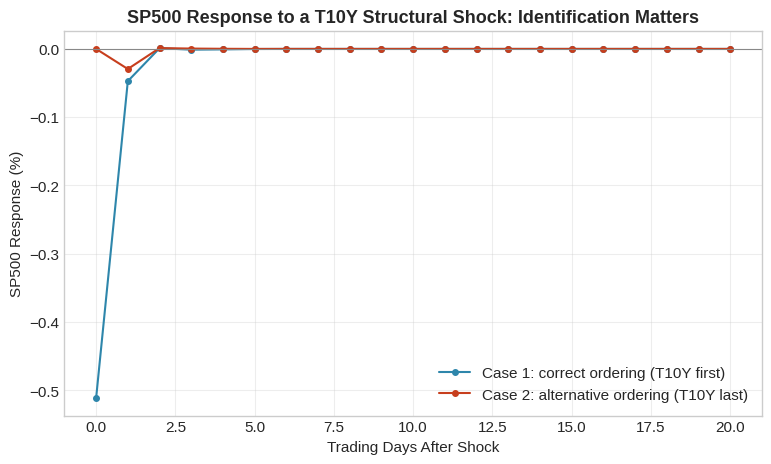

In [9]:
def compute_irf(A_list, P, horizon):
    k = A_list[0].shape[0]
    p = len(A_list)
    Phi = [np.eye(k)]
    for h in range(1, horizon + 1):
        Ph = np.zeros((k, k))
        for i in range(1, min(h, p) + 1):
            Ph += A_list[i-1] @ Phi[h-i]
        Phi.append(Ph)
    return np.array([Phi[h] @ P for h in range(horizon + 1)])

horizon = 20
irf_case1 = compute_irf([A1_hat, A2_hat], P_correct, horizon)
resp_case1 = irf_case1[:, 2, 0]     # response of SP500 (idx 2) to the T10Y shock (idx 0), correct ordering

A1_hat_alt = A1_hat[np.ix_(order_alt, order_alt)]
A2_hat_alt = A2_hat[np.ix_(order_alt, order_alt)]
irf_case2 = compute_irf([A1_hat_alt, A2_hat_alt], P_alt, horizon)
resp_case2 = irf_case2[:, 0, 2]     # response of SP500 (now idx 0) to the T10Y shock (now idx 2), alt ordering

fig, ax = plt.subplots(figsize=(9, 5))
h_range = np.arange(horizon + 1)
ax.plot(h_range, resp_case1, 'o-', color='#2E86AB', markersize=4, label='Case 1: correct ordering (T10Y first)')
ax.plot(h_range, resp_case2, 'o-', color='#C73E1D', markersize=4, label='Case 2: alternative ordering (T10Y last)')
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xlabel('Trading Days After Shock'); ax.set_ylabel('SP500 Response (%)')
ax.set_title('SP500 Response to a T10Y Structural Shock: Identification Matters')
ax.legend()
plt.show()

print(f"Impact (h=0) response, correct ordering:     {resp_case1[0]:.3f}")
print(f"Impact (h=0) response, alternative ordering:  {resp_case2[0]:.3f}")

The correct ordering shows SP500 dropping about 0.5% on impact from a T10Y shock, decaying within a day or two, matching the true DGP. The alternative ordering shows **exactly zero** impact response, since the recursive assumption forces the last-ordered variable's shock to have no contemporaneous effect on anything, by construction. A real, sizable, same-day relationship is completely hidden by one modeling choice, illustrating why the identifying assumption has to be defended on economic grounds, not just algebraic convenience.

## 6. Rolling One-Week-Ahead Out-of-Sample Forecast

A genuine walk-forward test: at every trading day in the final two years of the sample, the VAR(2) model is refit on a trailing 2,000-day rolling window (about 8 years of history), then used to forecast the **cumulative return over the next 5 trading days** (one calendar week). The window then rolls forward one day, and the process repeats, 500 separate forecast origins in total, each with its own fresh model fit.

Note that SVAR's structural identification does not change these point forecasts at all, forecasting only depends on the reduced-form $A_i$ matrices, not on how the shocks are decomposed structurally. Structural identification matters for interpreting *shocks* (Section 5), not for forecasting *point values* (this section).

In [10]:
def forecast_var_path(Y_hist, coefs, p, h):
    k = Y_hist.shape[1]
    c_ = coefs[0]
    A_mats = [coefs[1+i*k:1+(i+1)*k].T for i in range(p)]
    hist = list(Y_hist[-p:])
    path = []
    for _ in range(h):
        y_next = c_.copy()
        for i in range(p):
            y_next += A_mats[i] @ hist[-1-i]
        hist.append(y_next)
        path.append(y_next)
    return np.array(path)

h, p_use = 5, 2
n_total = len(Y)
n_test = 500
train_window = 2000
start_idx = n_total - n_test - h

cum_forecasts = np.zeros((n_test, k))
cum_actuals = np.zeros((n_test, k))

for j in range(n_test):
    origin = start_idx + j
    Y_train = Y[max(0, origin - train_window): origin]
    coefs_j, _, _ = fit_var(Y_train, p_use)
    path = forecast_var_path(Y_train, coefs_j, p_use, h)
    cum_forecasts[j] = path.sum(axis=0)
    cum_actuals[j] = Y[origin: origin + h].sum(axis=0)

test_dates = df.index[start_idx + h - 1: start_idx + n_test + h - 1]
print(f"Rolling forecast complete: {n_test} weekly origins, VAR({p_use}) refit at each one")

Rolling forecast complete: 500 weekly origins, VAR(2) refit at each one


**Diagram - forecast vs. actual.** The 1-week-ahead cumulative-return forecast against what actually happened, for all three series.

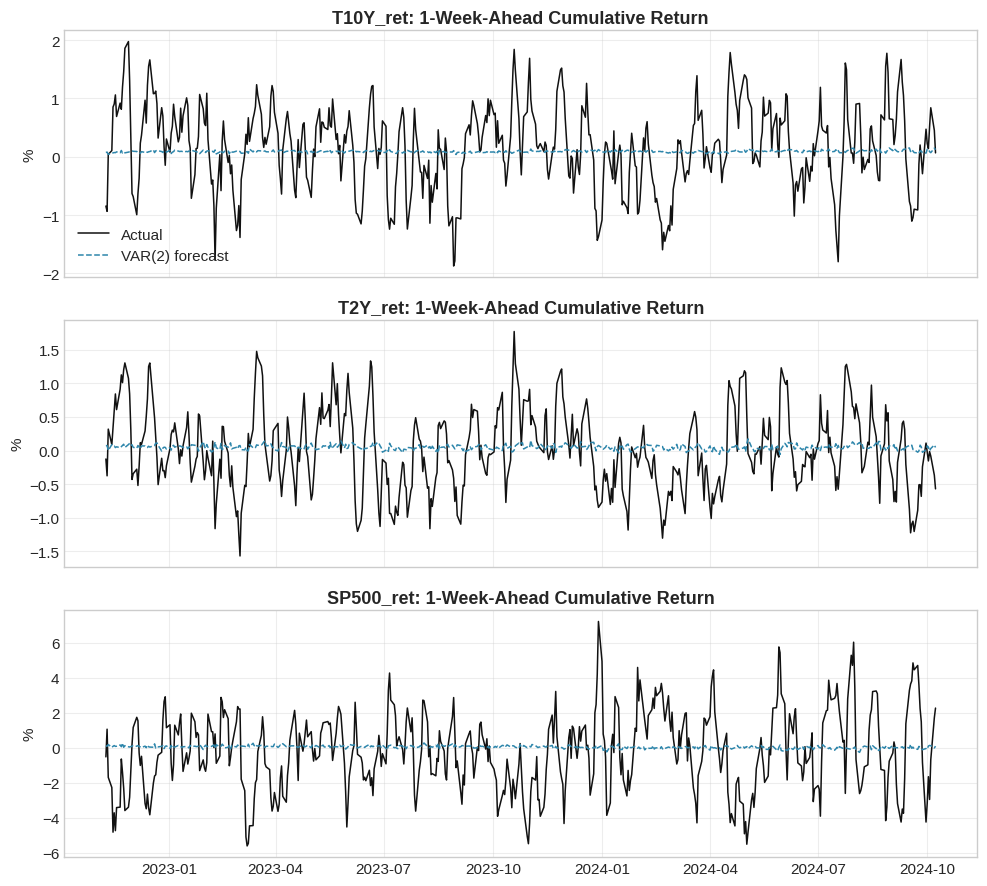

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for i, (ax, name) in enumerate(zip(axes, names)):
    ax.plot(test_dates, cum_actuals[:, i], color='#111111', linewidth=1.1, label='Actual')
    ax.plot(test_dates, cum_forecasts[:, i], color='#2E86AB', linewidth=1.1, linestyle='--', label='VAR(2) forecast')
    ax.set_title(f'{name}: 1-Week-Ahead Cumulative Return')
    ax.set_ylabel('%')
    if i == 0: ax.legend()
plt.tight_layout()
plt.show()

**Error analysis.** RMSE against two natural benchmarks: predicting **zero** cumulative return (a fair benchmark when weekly return predictability is genuinely weak), and **persistence** (naively repeating last week's realized cumulative return).

           VAR(2) RMSE  Zero-forecast RMSE  Persistence RMSE  Improvement vs. zero (%)  Corr(forecast, actual)
T10Y_ret        0.7256              0.7381            1.0262                    1.6907                 -0.0650
T2Y_ret         0.6006              0.5988            0.8316                   -0.2974                  0.0174
SP500_ret       2.2771              2.2660            3.1952                   -0.4882                 -0.0685


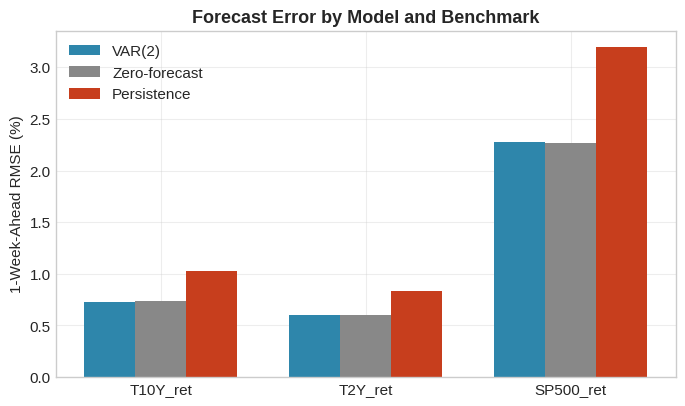

In [12]:
rmse_var = np.sqrt(np.mean((cum_forecasts - cum_actuals) ** 2, axis=0))
rmse_zero = np.sqrt(np.mean(cum_actuals ** 2, axis=0))

persistence_fc = np.array([Y[start_idx + j - h: start_idx + j].sum(axis=0) for j in range(n_test)])
rmse_persist = np.sqrt(np.mean((persistence_fc - cum_actuals) ** 2, axis=0))

corr = [np.corrcoef(cum_forecasts[:, i], cum_actuals[:, i])[0, 1] for i in range(k)]

summary = pd.DataFrame({
    'VAR(2) RMSE': rmse_var, 'Zero-forecast RMSE': rmse_zero, 'Persistence RMSE': rmse_persist,
    'Improvement vs. zero (%)': 100 * (1 - rmse_var / rmse_zero),
    'Corr(forecast, actual)': corr,
}, index=names)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.25
x_pos = np.arange(k)
ax.bar(x_pos - width, rmse_var, width, color='#2E86AB', label='VAR(2)')
ax.bar(x_pos, rmse_zero, width, color='#888888', label='Zero-forecast')
ax.bar(x_pos + width, rmse_persist, width, color='#C73E1D', label='Persistence')
ax.set_xticks(x_pos); ax.set_xticklabels(names)
ax.set_ylabel('1-Week-Ahead RMSE (%)')
ax.set_title('Forecast Error by Model and Benchmark')
ax.legend()
plt.show()